**imports**-Cell 1

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib . pyplot as plt
import numpy as np
print ('tf version :', tf . __version__ )

tf version : 2.20.0


**load MNIST**-Cell 2

In [ ]:
# Load the dataset that comes built into Keras
( x_train, y_train ), ( x_test, y_test ) = tf . keras . datasets . fashion_mnist . load_data ()
# Normalise pixel values from 0..255 to 0..1 ( helps training )
x_train = x_train.astype ('float32') / 255.0
x_test = x_test.astype ('float32') / 255.0
print ('train shape :', x_train . shape ) # (60000 , 28 , 28)
print ('test shape :', x_test . shape ) # (10000 , 28 , 28)

train shape : (60000, 28, 28)
test shape : (10000, 28, 28)


**peek at 16 random images**-Cell 3

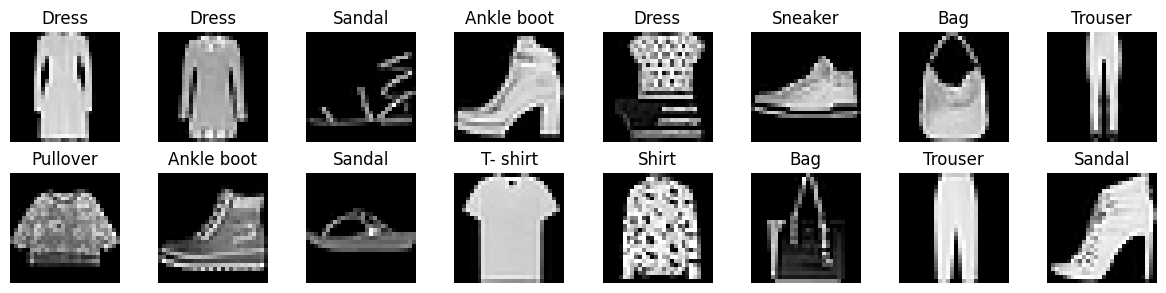

In [ ]:
fig, axes = plt.subplots (2, 8, figsize =(12, 3) )
class_names = ['T- shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']
for ax in axes.flat:
    i = np.random.randint(len(x_train))
    ax.imshow( x_train [ i ] , cmap ='gray')
    ax. set_title ( class_names [ y_train [i ]])
    ax.axis('off')
plt.tight_layout () ; plt.show ()

**build the CNN**-Cell 4

In [ ]:
model = models . Sequential ([
    # Reshape adds a " channel " dimension : (28 , 28) -> (28 , 28 , 1)
    layers . Reshape ((28 , 28 , 1) , input_shape =(28 , 28) ) ,
    # Conv layer 1: 8 filters of size 3x3 + ReLU activation
    layers . Conv2D (8 , 3 , activation ='relu', padding ='same') ,
    layers . MaxPooling2D (2) , # halve spatial size
    # Conv layer 2: 16 filters
    layers . Conv2D (16 , 3 , activation ='relu', padding ='same') ,
    layers . MaxPooling2D (2) ,
    #Add a third Conv layer
    layers . Conv2D (32 , 3 , activation ='relu', padding ='same') ,
    layers . MaxPooling2D (2) ,
    # Flatten 7 x7x16 = 784 numbers -> a single long vector
    layers . Flatten () ,
    layers . Dense (32 , activation ='relu') ,
    # 10 output classes -> softmax gives 10 probabilities that sum to 1
    layers . Dense (10 , activation ='softmax') ,
])
model . compile (
    optimizer ='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics =[ 'accuracy'])
model . summary ()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_4 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,466 (60.41 KB)

 Trainable params: 15,466 (60.41 KB)

 Non-trainable params: 0 (0.00 B)

**train for 5 epochs**-Cell 5

In [ ]:
history = model . fit (
    x_train , y_train ,
    epochs =15 ,
    validation_split =0.1 ,
    batch_size =128 ,
    verbose =2)

Epoch 1/15
422/422 - 25s - 60ms/step - accuracy: 0.8825 - loss: 0.3282 - val_accuracy: 0.8783 - val_loss: 0.3338
Epoch 2/15
422/422 - 40s - 94ms/step - accuracy: 0.8865 - loss: 0.3125 - val_accuracy: 0.8842 - val_loss: 0.3241
Epoch 3/15
422/422 - 42s - 100ms/step - accuracy: 0.8919 - loss: 0.3010 - val_accuracy: 0.8843 - val_loss: 0.3141
Epoch 4/15
422/422 - 25s - 59ms/step - accuracy: 0.8949 - loss: 0.2903 - val_accuracy: 0.8875 - val_loss: 0.3148
Epoch 5/15
422/422 - 24s - 56ms/step - accuracy: 0.8990 - loss: 0.2784 - val_accuracy: 0.8925 - val_loss: 0.2899
Epoch 6/15
422/422 - 25s - 58ms/step - accuracy: 0.9003 - loss: 0.2721 - val_accuracy: 0.8897 - val_loss: 0.2934
Epoch 7/15
422/422 - 41s - 98ms/step - accuracy: 0.9031 - loss: 0.2657 - val_accuracy: 0.8955 - val_loss: 0.2886
Epoch 8/15
422/422 - 24s - 57ms/step - accuracy: 0.9053 - loss: 0.2589 - val_accuracy: 0.8960 - val_loss: 0.2873
Epoch 9/15
422/422 - 25s - 59ms/step - accuracy: 0.9088 - loss: 0.2523 - val_accuracy: 0.8937 -

**plot accuracy curves**-Cell 6

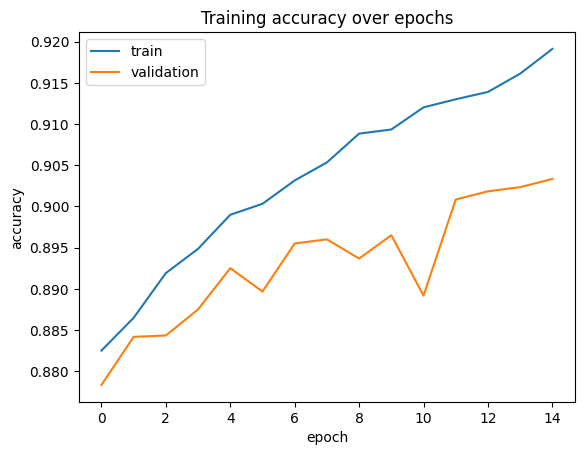

In [ ]:
plt . plot ( history . history ['accuracy'] , label ='train')
plt . plot ( history . history ['val_accuracy'] , label ='validation')
plt . xlabel ('epoch') ; plt . ylabel ('accuracy') ; plt . legend ()
plt . title ('Training accuracy over epochs')
plt . show ()

**evaluate on the test set**-Cell 7

In [ ]:
test_loss , test_acc = model . evaluate ( x_test , y_test , verbose =0)
print ( f'Test accuracy on MNIST : { test_acc :.2%}')

Test accuracy on MNIST : 89.87%


**confusion matrix**-Cell 8

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


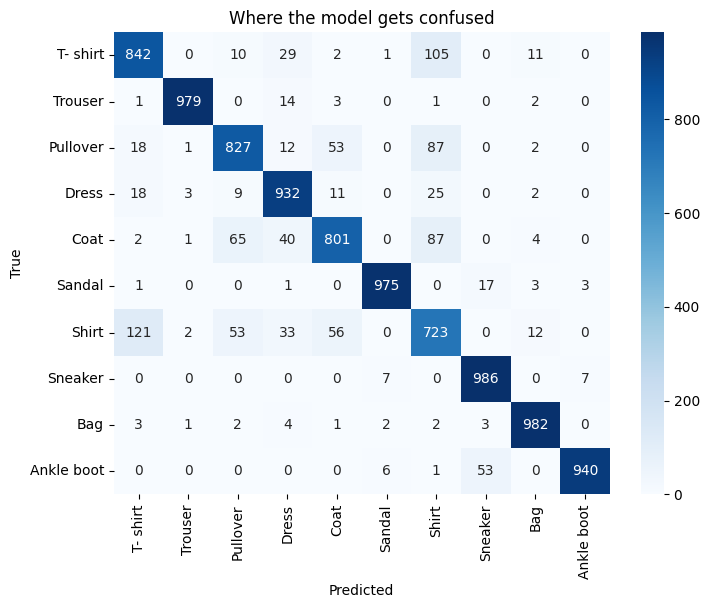

In [ ]:
from sklearn . metrics import confusion_matrix
import seaborn as sns

preds = model . predict ( x_test ) . argmax ( axis =1)
cm = confusion_matrix ( y_test , preds )

plt . figure ( figsize =(8 , 6) )
sns . heatmap ( cm , annot = True , fmt ='d', cmap ='Blues',
               xticklabels = class_names , yticklabels = class_names )
plt . xlabel ('Predicted') ; plt . ylabel ('True')
plt . title ('Where the model gets confused') ; plt . show ()

**show 9 misclassified images**-Cell 9

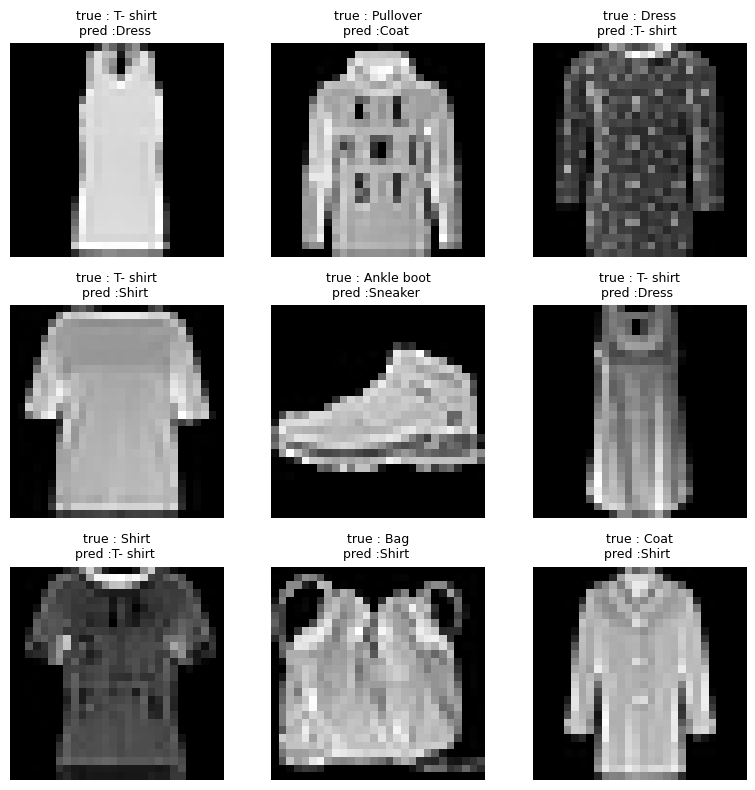

In [ ]:
wrong = np . where ( preds != y_test ) [0]
sample = np . random . choice ( wrong , 9 , replace = False )

fig , axes = plt . subplots (3 , 3 , figsize =(8 , 8) )
for ax , i in zip( axes . flat , sample ) :
    ax . imshow ( x_test [ i ] , cmap ='gray')
    ax . set_title ( f'true : { class_names [ y_test [i ]]}\npred :{ class_names [ preds [i]]} ',fontsize =9)
    ax . axis ('off')
plt . tight_layout () ; plt . show ()

# **TASK A1– Swap the dataset to Fashion-MNIST**

---



**Train accuracy after epoch 5(for Fashion-MNIST):**  *0.8877 or 88.77%*

**Test accuracy(for Fashion-MNIST):**  *88.17%*

**Did the gap between train and test grow vs MNIST?:**

The MNIST training accuracy (98.38%) and testing accuracy (98.20%) had a tiny gap of only 0.18%. The new Fashion-MNIST has a training accuracy of 88.77% and testing accuracy of 88.17%. The Fashion-MNIST has a gap of 0.60%. The gap grew by 0.42% because clothing patterns (like the difference between a Coat and a Pullover) are much more complex and varied than simple written digits. This makes it harder for the network to generalize perfectly to the test set, leading to a wider gap.


---



# **TASK A2– Add a third Conv layer**


---


The model's test accuracy dropped from 88.17% down to 86.92%.(overfitting)

**The test accuracy went down by 1.25%.**


---




#**TASK A3– Train longer and watch for overfitting**


---
The validation accuracy stops improving around **epoch 7 or 8** when it hits 89.60% and just stays around that same number(89-90). Even though the validation scores stop improving, the training accuracy keeps going up every single epoch from 88.25% to 91.91%. This happens when a model learns the training data too perfectly but cannot get better at new data, and it is called **overfitting**.

---





#**TASK A4– Confusion matrix**


---
The 3 most-confused class pairs as (true_class, predicted_class, count):




1.   (Shirt, T-shirt, 121)

1.   (T-shirt, Shirt, 105)
3.   (Pullover, Shirt, 87) or (Coat, Shirt, 87)


---












#**TASK A5– Misclassified images**


---
1.  Image 1 (true: T-shirt, pred: Dress - top left): As it is very blurred a human would definitely struggle here because the clothing is extremely long and sleeveless, making it look much more like a dress than a regular T-shirt.

2.  Image 5 (true: Ankle boot, pred: Sneaker - middle): A human would struggle with this one because it looks exactly like a  sneaker, and as it is very blurred, it is really difficult to tell if it is actually a boot.

3.  Image 8 (true: Bag, pred: Shirt - bottom center): A human would not struggle here because the shoulder straps and structure make it look clearly like a backpack rather than a shirt.


---



##Task A6 – Reflection



---
Which two classes does your CNN confuse most?  Why do you think that’s happening (from the images, not the model)? If you had to fix this for production, what would you try? (More data? Bigger images? Colour
photos?)

*My model gets confused the most on two classes, which are Shirts and T-shirts. This can be seen as they have the highest error counts of 121 and 105. This happens because shirts and T-shirts look almost exactly the same when they are shrunk down into tiny, low-resolution images. They also have similar shape and structure which makes it harder for the machine to distinguish between them. The pictures are also very blurry, hence it is very hard to see key distinguishing features like shirt collars or button lines. If I had to fix this for production, I would try using bigger, high-resolution images and colour photos. Adding more data would also help a lot as it would train the model better. As the images are now more clear and colourful, more features could be extracted.*



**STRETCH-
Add data augmentation.(got some edits from google in this)**

In [ ]:
# CELL 10 - STRETCH TASK: Data Augmentation Model
stretch_model = models.Sequential([
    # 1. Augmentation layers go first
    layers . RandomFlip ('horizontal', input_shape=(28, 28, 1)),
    layers . RandomRotation (0.1) ,
    # Reshape adds a " channel " dimension : (28 , 28) -> (28 , 28 , 1)
    layers . Reshape ((28 , 28 , 1)) ,
    # Conv layer 1: 8 filters of size 3x3 + ReLU activation
    layers . Conv2D (8 , 3 , activation ='relu', padding ='same') ,
    layers . MaxPooling2D (2) , # halve spatial size
    # Conv layer 2: 16 filters
    layers . Conv2D (16 , 3 , activation ='relu', padding ='same') ,
    layers . MaxPooling2D (2) ,
    #Add a third Conv layer
    layers . Conv2D (32 , 3 , activation ='relu', padding ='same') ,
    layers . MaxPooling2D (2) ,
    # Flatten 7 x7x16 = 784 numbers -> a single long vector
    layers . Flatten () ,
    layers . Dense (32 , activation ='relu') ,
    # 10 output classes -> softmax gives 10 probabilities that sum to 1
    layers . Dense (10 , activation ='softmax') ,
])

# Compile the new stretch model
stretch_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the stretch model for 15 epochs
print("Training model with Data Augmentation...")
stretch_history = stretch_model.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=128,
    verbose=2
)

# Evaluate the new stretch model on the test set
print("\nEvaluating Stretch Model:")
stretch_loss, stretch_acc = stretch_model.evaluate(x_test, y_test, verbose=0)
print(f"New Test Accuracy with Augmentation: {stretch_acc:.2%}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training model with Data Augmentation...
Epoch 1/15
422/422 - 31s - 74ms/step - accuracy: 0.6498 - loss: 0.9826 - val_accuracy: 0.7633 - val_loss: 0.6525
Epoch 2/15
422/422 - 30s - 72ms/step - accuracy: 0.7696 - loss: 0.6386 - val_accuracy: 0.7915 - val_loss: 0.5765
Epoch 3/15
422/422 - 28s - 67ms/step - accuracy: 0.7930 - loss: 0.5701 - val_accuracy: 0.8023 - val_loss: 0.5377
Epoch 4/15
422/422 - 29s - 68ms/step - accuracy: 0.8101 - loss: 0.5280 - val_accuracy: 0.8138 - val_loss: 0.5075
Epoch 5/15
422/422 - 41s - 97ms/step - accuracy: 0.8196 - loss: 0.4994 - val_accuracy: 0.8083 - val_loss: 0.5193
Epoch 6/15
422/422 - 40s - 95ms/step - accuracy: 0.8274 - loss: 0.4772 - val_accuracy: 0.8282 - val_loss: 0.4675
Epoch 7/15
422/422 - 28s - 67ms/step - accuracy: 0.8339 - loss: 0.4622 - val_accuracy: 0.8147 - val_loss: 0.4940
Epoch 8/15
422/422 - 41s - 98ms/step - accuracy: 0.8372 - loss: 0.4488 - val_accuracy: 0.8383 - val_loss: 0.4377
Epoch 9/15
422/422 - 42s - 100ms/step - accuracy: 0.842

#**STRETCH**


---



**New Training Accuracy (Epoch 15): 85.75%**

**New Test Accuracy (With Augmentation): 85.56%**

**Did the gap between train and test accuracy shrink?: Yes,the gap between the train and test accuracy shrunk by nearly 1.85%. The current gap between train and test accuracy is 0.19% and the gap before augmentation was 2.04%.**

**Why augmentation helps: Data augmentation stops the model from just memorizing the exact pictures in the training setup. By flipping and twisting the images, it forces the model to learn the actual shapes and patterns, making it much smarter at guessing brand-new test images correctly.**


---

